## 1. Importing Libraries

**Importing necessary libraries**

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Loading Dataset

**Loading Dataset in a variable named as - "df"**

In [13]:
df=pd.read_csv("Advertising.csv")

### 3.1 Basic Data Inspection

## 3. Exploratory Data Analysis (EDA)

**Checking dataset's shape**

In [14]:
df.shape

(200, 5)

**Checking dataset's information**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


**Describing Dataset**

In [16]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


**Checking Null Values**

In [17]:
df.notnull().sum()

Unnamed: 0    200
TV            200
Radio         200
Newspaper     200
Sales         200
dtype: int64

**Checking top 5 ovservations**

In [18]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### 3.2 Drop Unnecessary Column

In [19]:
df=df.drop("Unnamed: 0",axis=1)

In [40]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


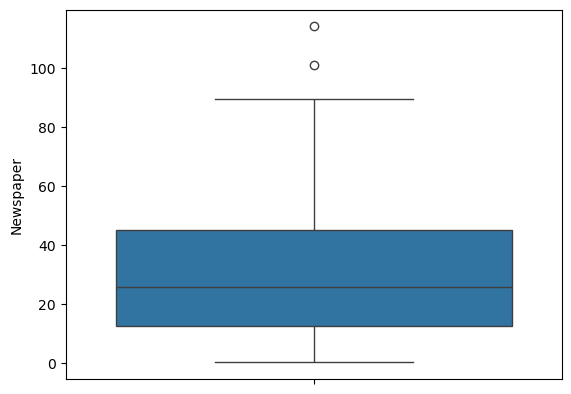

In [46]:
sns.boxplot(data=df["Newspaper"])
plt.show()

### 4.1 Outlier Detection

In [52]:
df["Newspaper"].skew()

np.float64(0.8947204074986175)

### 3.3 Distribution Plots

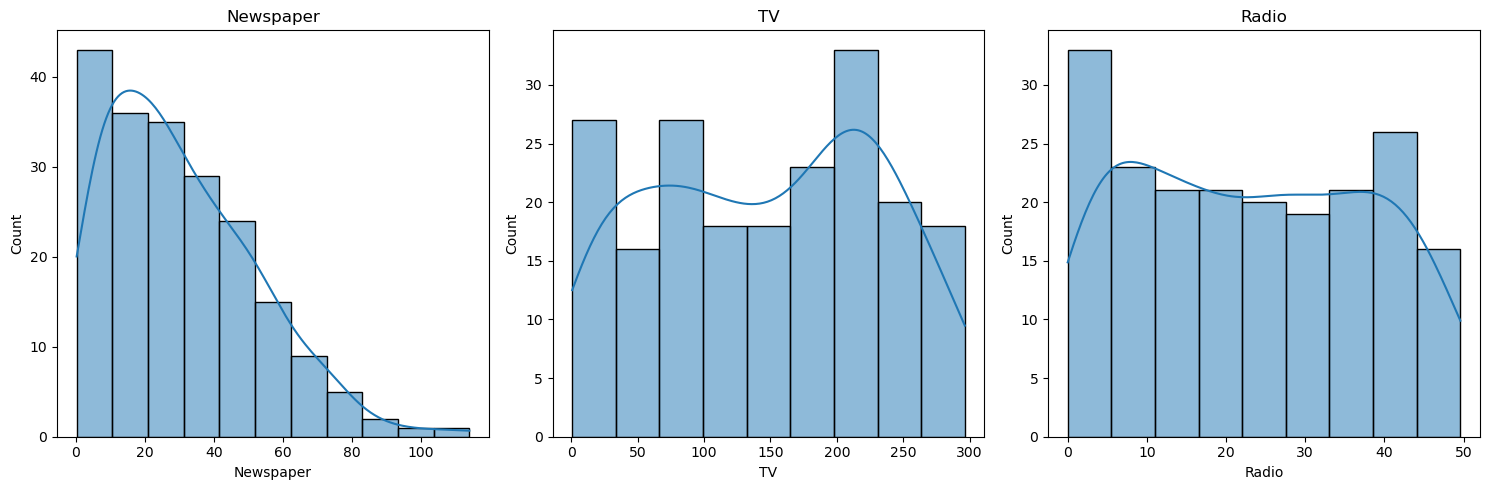

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df["Newspaper"],kde=True)
plt.title("Newspaper")

plt.subplot(1,3,2)
sns.histplot(df["TV"],kde=True)
plt.title("TV")

plt.subplot(1,3,3)
sns.histplot(df["Radio"],kde=True)
plt.title("Radio")

plt.tight_layout()
plt.show()

### 3.4 Scatter Plots (Feature vs Sales)

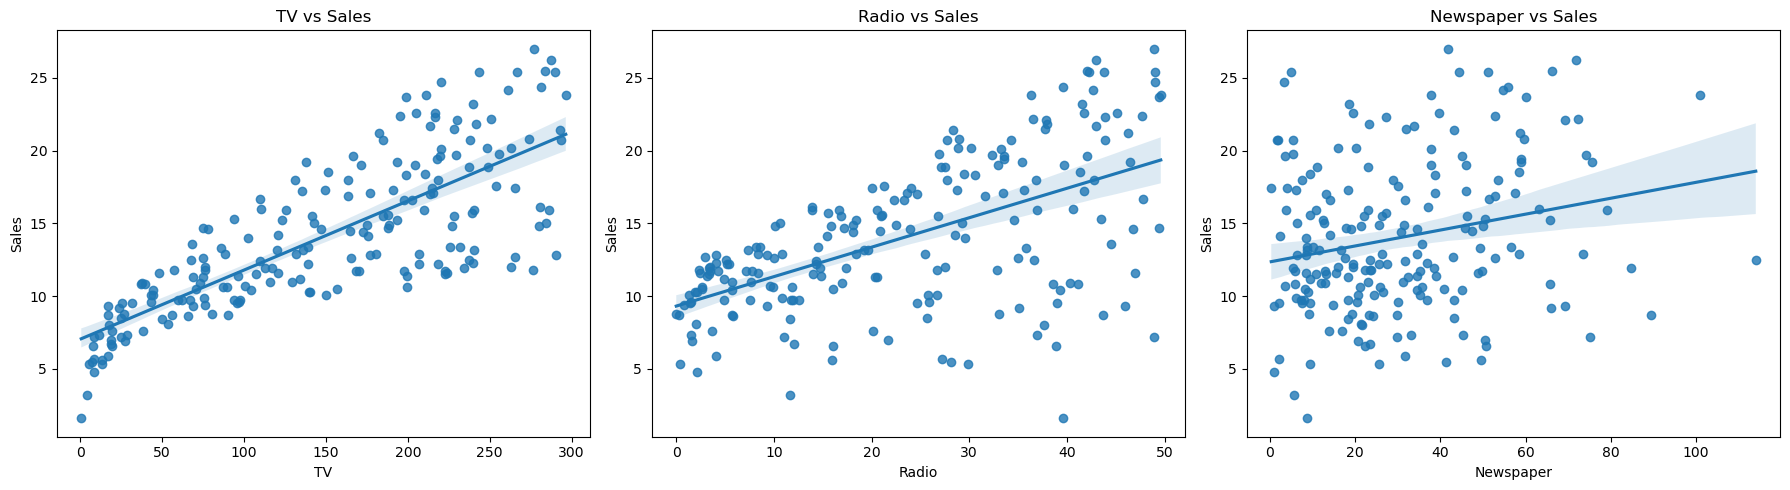

In [23]:
plt.figure(figsize=(18,5))

# TV
plt.subplot(1,3,1)
sns.regplot(data=df, x="TV", y="Sales")
plt.title("TV vs Sales")

# Radio
plt.subplot(1,3,2)
sns.regplot(data=df, x="Radio", y="Sales")
plt.title("Radio vs Sales")

# Newspaper
plt.subplot(1,3,3)
sns.regplot(data=df, x="Newspaper", y="Sales")
plt.title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

### 3.5 Pairplot

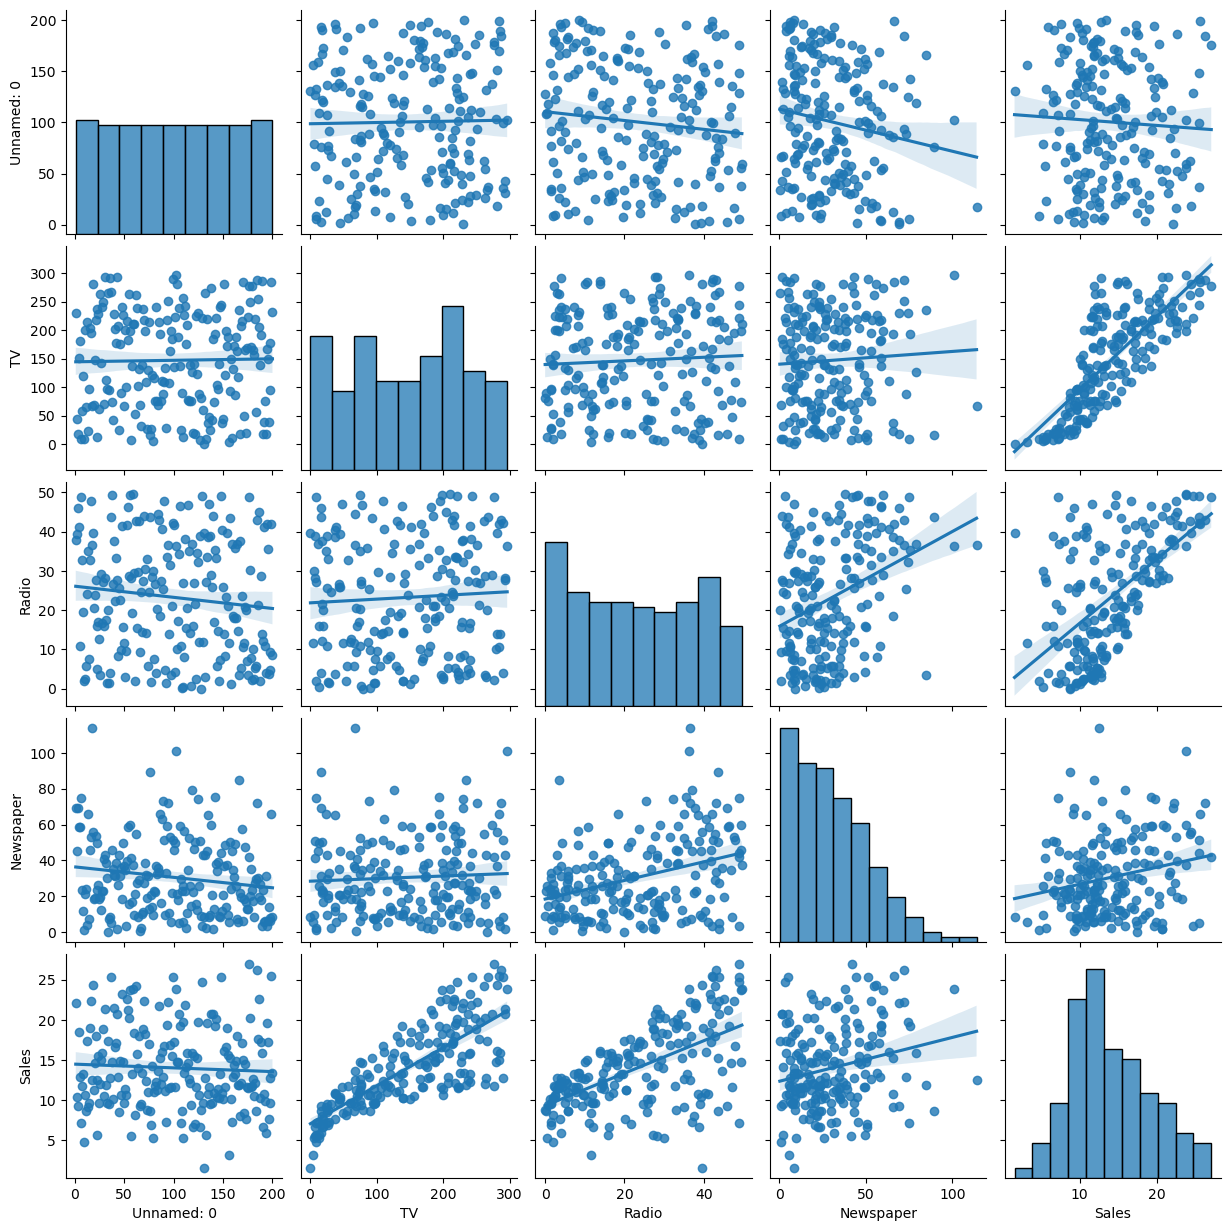

In [26]:
sns.pairplot(df,kind="reg")
plt.show()

### 3.6 Correlation Heatmap

In [20]:
percentile25 = df['Newspaper'].quantile(0.25)
percentile75 = df['Newspaper'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 93.625
Lower limit -35.775000000000006


In [21]:
df[df['Newspaper'] > upper_limit]

,TV,Radio,Newspaper,Sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


In [22]:
df[df['Newspaper'] < lower_limit]

,TV,Radio,Newspaper,Sales


**Using cabing to remove outlieres completly**

### 4.2 Outlier Treatment (Capping)

In [23]:
new_df = df

new_df['Newspaper'] = np.where(
    new_df['Newspaper'] > upper_limit,
    upper_limit,
    np.where(
        new_df['Newspaper'] < lower_limit,
        lower_limit,
        new_df['Newspaper']
    )
)

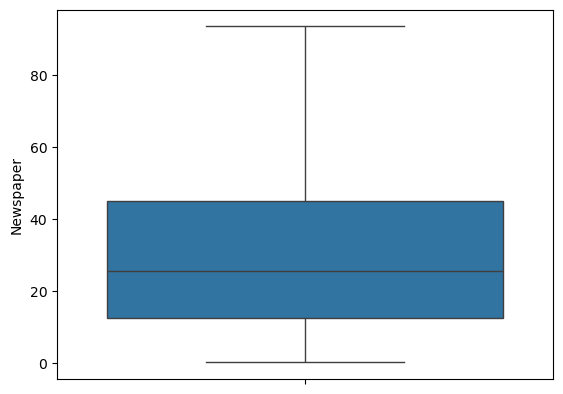

In [73]:
sns.boxplot(data=new_df["Newspaper"])
plt.show()

In [74]:
new_df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [75]:
new_df.shape

(200, 4)

In [76]:
new_df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.415750,14.022500
std,85.854236,14.846809,21.316901,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,93.625000,27.000000


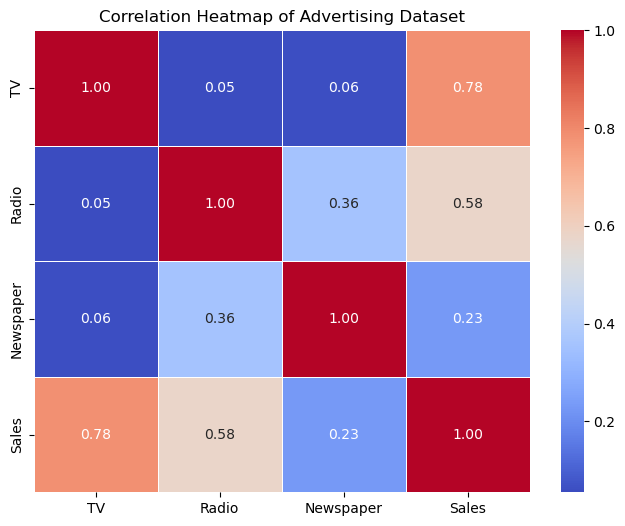

In [88]:
corr_matrix = new_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,         
    cmap="coolwarm",     
    fmt=".2f",           
    linewidths=0.5
)
plt.title("Correlation Heatmap of Advertising Dataset")
plt.show()

## 4. Data Preprocessing

**Data Splitting**

### 4.3 Data Splitting

In [24]:
X=new_df[["TV","Radio","Newspaper"]]
y=new_df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

**Scaling Data**

### 4.4 Feature Scaling

In [25]:
scaler=StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model - LinearRegression**

### 5.1 Linear Regression

## 5. Model Building & Evaluation

In [ ]:
model=LinearRegression()

In [103]:
model.fit(X_train_scaled,y_train)

LinearRegression()

In [105]:
Prediction=model.predict(X_test_scaled)

In [112]:
print("MAE  :", mean_absolute_error(y_test, Prediction))
print("MSE  :", mean_squared_error(y_test, Prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, Prediction)))
print("R²   :", r2_score(y_test, Prediction))

MAE  : 1.4921119631398472
MSE  : 3.7245756665929663
RMSE : 1.9299159739721743
R²   : 0.8556867461514709


**Model - RandomForestRegressor**

### 5.2 Random Forest Regressor

In [45]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model with hyperparameters
# n_estimators is the number of trees in the forest
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled,y_train)

# Make predictions
Prediction = model.predict(X_test_scaled)

In [46]:
print("MAE  :", mean_absolute_error(y_test, Prediction))
print("MSE  :", mean_squared_error(y_test, Prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, Prediction)))
print("R²   :", r2_score(y_test, Prediction))

MAE  : 0.5463939393939389
MSE  : 0.430271303030303
RMSE : 0.6559506864317645
R²   : 0.9833286104683303


**Checking that my model is in overfit or not**

In [49]:
model.score(X_train_scaled, y_train)

0.9957498452587124

In [50]:
model.score(X_test_scaled, y_test)

0.9833286104683303

**Model - Gradient boost regression**

### 5.3 Gradient Boosting Regressor

In [30]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train_scaled,y_train)

Prediction = gbr.predict(X_test_scaled)
print("MAE  :", mean_absolute_error(y_test, Prediction))
print("MSE  :", mean_squared_error(y_test, Prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, Prediction)))
print("R²   :", r2_score(y_test, Prediction))

MAE  : 0.5558916232704715
MSE  : 0.5546163963592716
RMSE : 0.7447257188786162
R²   : 0.9785107072694896


**Checking that my model is in overfit or not**

In [32]:
gbr.score(X_train_scaled, y_train)

0.9785107072694896

In [33]:
gbr.score(X_test_scaled, y_test)

0.9785107072694896

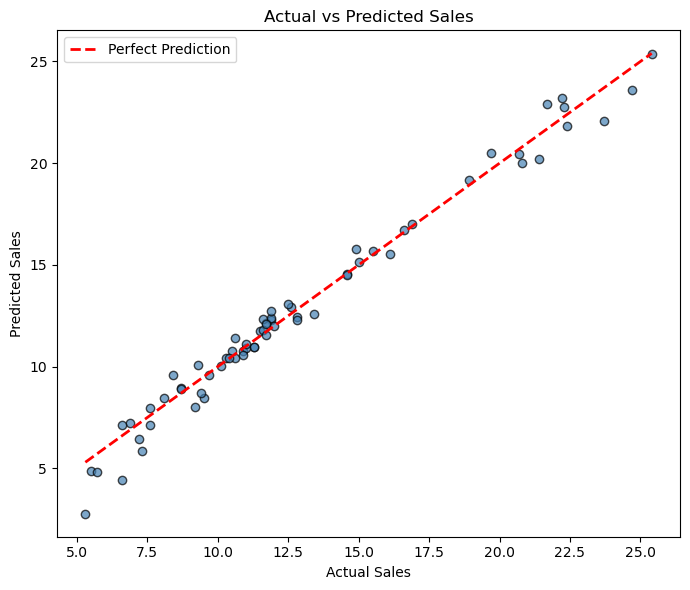

In [36]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, Prediction, color='steelblue', edgecolors='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

### 6.1 Actual vs Predicted

## 6. Result Visualization

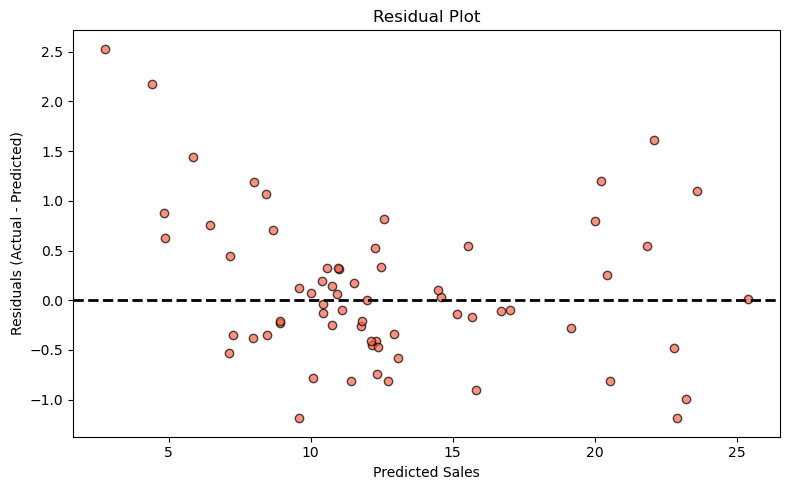

In [37]:
residuals = y_test - Prediction

plt.figure(figsize=(8, 5))
plt.scatter(Prediction, residuals, color='tomato', edgecolors='k', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

### 6.2 Residual Plot

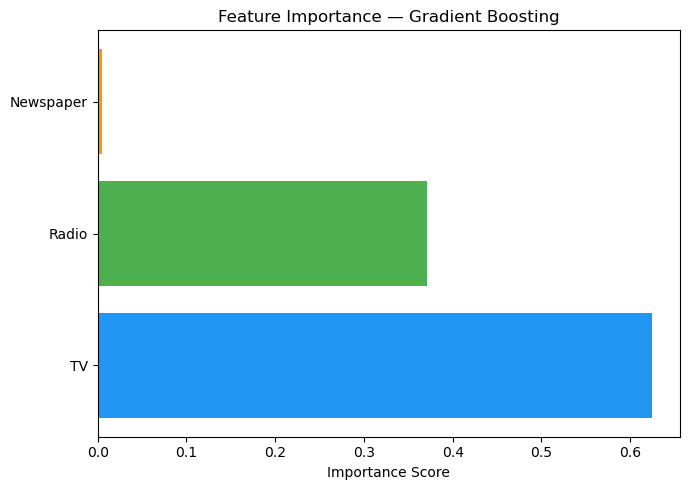

In [38]:
feature_names = ["TV", "Radio", "Newspaper"]
importances = gbr.feature_importances_

plt.figure(figsize=(7, 5))
plt.barh(feature_names, importances, color=['#2196F3', '#4CAF50', '#FF9800'])
plt.xlabel("Importance Score")
plt.title("Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.show()

### 6.3 Feature Importance

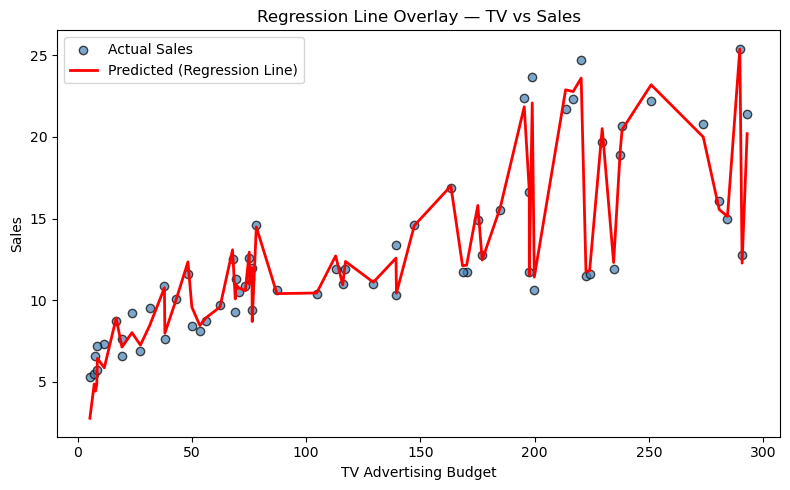

In [39]:
# Use TV feature only for this visualization
X_tv = X_test[["TV"]].values
y_pred_line = Prediction  # already predicted using all 3 features

# Sort by TV for a clean line
sorted_idx = np.argsort(X_tv[:, 0])

plt.figure(figsize=(8, 5))
plt.scatter(X_tv, y_test, color='steelblue', label='Actual Sales', alpha=0.7, edgecolors='k')
plt.plot(X_tv[sorted_idx], y_pred_line[sorted_idx], color='red', lw=2, label='Predicted (Regression Line)')
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Regression Line Overlay — TV vs Sales")
plt.legend()
plt.tight_layout()
plt.show()

### 6.4 Regression Line Overlay

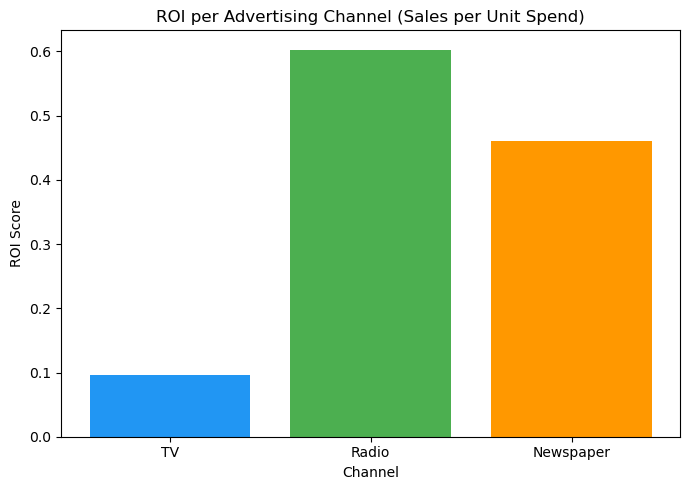

TV: 0.0954
Radio: 0.6028
Newspaper: 0.4610


In [40]:
roi = {}
for col in ['TV', 'Radio', 'Newspaper']:
    roi[col] = df['Sales'].sum() / df[col].sum()

plt.figure(figsize=(7, 5))
plt.bar(roi.keys(), roi.values(), color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title("ROI per Advertising Channel (Sales per Unit Spend)")
plt.ylabel("ROI Score")
plt.xlabel("Channel")
plt.tight_layout()
plt.show()

for k, v in roi.items():
    print(f"{k}: {v:.4f}")

### 7.1 ROI per Advertising Channel

## 7. Business Insights

In [41]:
tv_bins = pd.cut(df['TV'], bins=5)
print(df.groupby(tv_bins, observed=True)['Sales'].mean().round(2))

radio_bins = pd.cut(df['Radio'], bins=5)
print(df.groupby(radio_bins, observed=True)['Sales'].mean().round(2))

TV
(0.404, 59.84]       7.89
(59.84, 118.98]     11.51
(118.98, 178.12]    14.38
(178.12, 237.26]    17.14
(237.26, 296.4]     19.22
Name: Sales, dtype: float64
Radio
(-0.0496, 9.92]    10.47
(9.92, 19.84]      11.98
(19.84, 29.76]     14.55
(29.76, 39.68]     15.43
(39.68, 49.6]      19.14
Name: Sales, dtype: float64


### 7.2 Spend vs Sales Analysis

In [42]:
print(f"Newspaper-Sales Correlation: {df['Newspaper'].corr(df['Sales']):.4f}")

news_bins = pd.cut(df['Newspaper'], bins=4)
print(df.groupby(news_bins, observed=True)['Sales'].mean().round(2))

Newspaper-Sales Correlation: 0.2314
Newspaper
(0.207, 23.631]     13.05
(23.631, 46.962]    13.91
(46.962, 70.294]    16.22
(70.294, 93.625]    16.38
Name: Sales, dtype: float64
